
# Домашнее задание №1.
### Wine Classification (mstz/wine)

**Цель:** закрепить практические шаги машинного обучения на другом датасете..

**Датасет:** `mstz/wine` (Wine Quality Dataset, Kaggle)  
**Задача:** бинарная классификация — определить, является ли вино красным.

**Целевая переменная:** `is_red`  
- 1 — красное вино  
- 0 — белое вино


In [2]:

!pip install -q datasets seaborn pandas matplotlib scikit-learn numpy


In [3]:

from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="talk", style="whitegrid")


## Загрузка датасета

In [4]:

dataset_dict = load_dataset("mstz/wine")

print("Сплиты и количество объектов:",
      {split: len(dataset_dict[split]) for split in dataset_dict})

print("\nСхема признаков (HF features):")
print(dataset_dict["train"].features)


Сплиты и количество объектов: {'train': 6497}

Схема признаков (HF features):
{'fixed_acidity': Value('float64'), 'volatile_acidity': Value('float64'), 'citric_acid': Value('float64'), 'residual_sugar': Value('float64'), 'chlorides': Value('float64'), 'free_sulfur_dioxide': Value('float64'), 'total_sulfur_dioxide': Value('float64'), 'density': Value('float64'), 'pH': Value('float64'), 'sulphates': Value('float64'), 'alcohol': Value('float64'), 'quality': Value('int64'), 'is_red': Value('int64')}


## Перевод в pandas

In [5]:

wine_dataframe = dataset_dict["train"].to_pandas()

print("\nРазмер таблицы (строки, колонки):", wine_dataframe.shape)
print("Колонки:", sorted(wine_dataframe.columns.tolist()))
wine_dataframe.head()



Размер таблицы (строки, колонки): (6497, 13)
Колонки: ['alcohol', 'chlorides', 'citric_acid', 'density', 'fixed_acidity', 'free_sulfur_dioxide', 'is_red', 'pH', 'quality', 'residual_sugar', 'sulphates', 'total_sulfur_dioxide', 'volatile_acidity']


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


## Определение признаков и целевой переменной

In [6]:

target_column = "is_red"

feature_columns = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
    "quality"
]

print("Целевая переменная:", target_column)
print("Количество признаков:", len(feature_columns))


Целевая переменная: is_red
Количество признаков: 12


## Проверка пропусков

In [7]:

wine_dataframe.isna().sum()


fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
is_red                  0
dtype: int64

## Типы признаков

In [8]:

numeric_columns = wine_dataframe.select_dtypes(include="number").columns.tolist()
categorical_columns = wine_dataframe.select_dtypes(exclude="number").columns.tolist()

print("Числовые признаки:", numeric_columns)
print("Категориальные признаки:", categorical_columns)


Числовые признаки: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'is_red']
Категориальные признаки: []


## Базовая статистика

In [9]:

(
    wine_dataframe[numeric_columns]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .round(2)
)


,mean,std,min,max
fixed_acidity,7.22,1.30,3.80,15.90
volatile_acidity,0.34,0.16,0.08,1.58
citric_acid,0.32,0.15,0.00,1.66
residual_sugar,5.44,4.76,0.60,65.80
chlorides,0.06,0.04,0.01,0.61
free_sulfur_dioxide,30.53,17.75,1.00,289.00
total_sulfur_dioxide,115.74,56.52,6.00,440.00
density,0.99,0.00,0.99,1.04
pH,3.22,0.16,2.72,4.01
sulphates,0.53,0.15,0.22,2.00


## Баланс классов

In [10]:

wine_dataframe["is_red"].value_counts(normalize=True).round(3)


is_red
1    0.754
0    0.246
Name: proportion, dtype: float64

## Визуализация разделимости

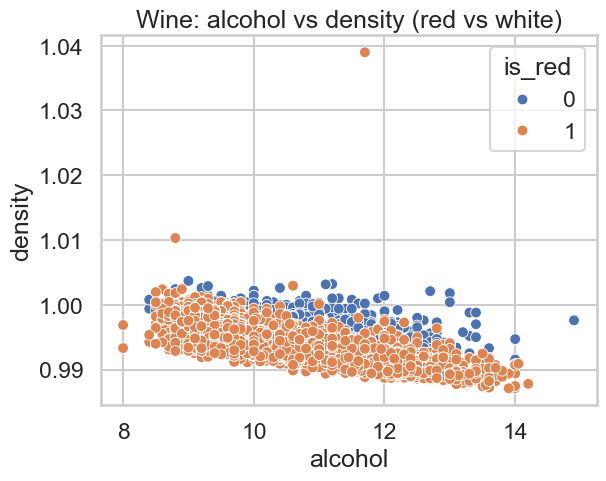

In [11]:

sns.scatterplot(
    data=wine_dataframe,
    x="alcohol",
    y="density",
    hue="is_red",
    s=60
)
plt.title("Wine: alcohol vs density (red vs white)")
plt.show()


## Train / Test split

In [12]:

from sklearn.model_selection import train_test_split

X = wine_dataframe[feature_columns].copy()
y = wine_dataframe[target_column].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)


X_train: (4547, 12) | X_test: (1950, 12)
y_train: (4547,) | y_test: (1950,)



## Масштабирование признаков

Используем StandardScaler, так как признаки имеют разные масштабы.  
Это особенно важно для линейных моделей и kNN.


## Модель 1: Logistic Regression

In [13]:

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

logreg_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]
)

logreg_pipeline.fit(X_train, y_train)
logreg_predictions = logreg_pipeline.predict(X_test)

logreg_accuracy = accuracy_score(y_test, logreg_predictions)
logreg_f1_macro = f1_score(y_test, logreg_predictions, average="macro")

print("Accuracy:", round(logreg_accuracy, 3))
print("F1-macro:", round(logreg_f1_macro, 3))


Accuracy: 0.992
F1-macro: 0.989


In [14]:

print(classification_report(y_test, logreg_predictions, digits=3))


              precision    recall  f1-score   support

           0      0.985     0.981     0.983       480
           1      0.994     0.995     0.995      1470

    accuracy                          0.992      1950
   macro avg      0.990     0.988     0.989      1950
weighted avg      0.992     0.992     0.992      1950



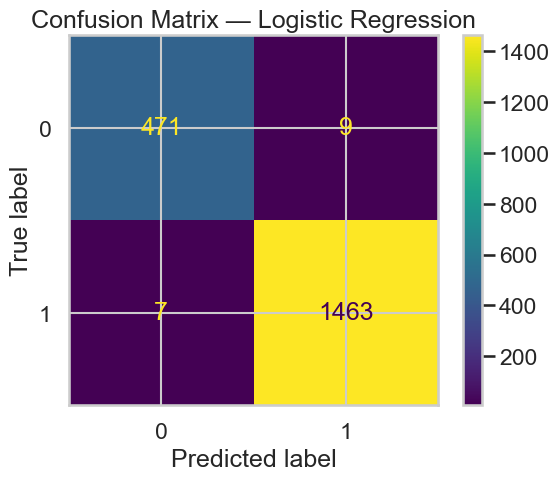

In [15]:

ConfusionMatrixDisplay.from_predictions(y_test, logreg_predictions)
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


## Модель 2: kNN

In [16]:

from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]
)

knn_pipeline.fit(X_train, y_train)
knn_predictions = knn_pipeline.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_f1_macro = f1_score(y_test, knn_predictions, average="macro")

print("Accuracy:", round(knn_accuracy, 3))
print("F1-macro:", round(knn_f1_macro, 3))


Accuracy: 0.993
F1-macro: 0.99


In [17]:

print(classification_report(y_test, knn_predictions, digits=3))


              precision    recall  f1-score   support

           0      0.985     0.985     0.985       480
           1      0.995     0.995     0.995      1470

    accuracy                          0.993      1950
   macro avg      0.990     0.990     0.990      1950
weighted avg      0.993     0.993     0.993      1950



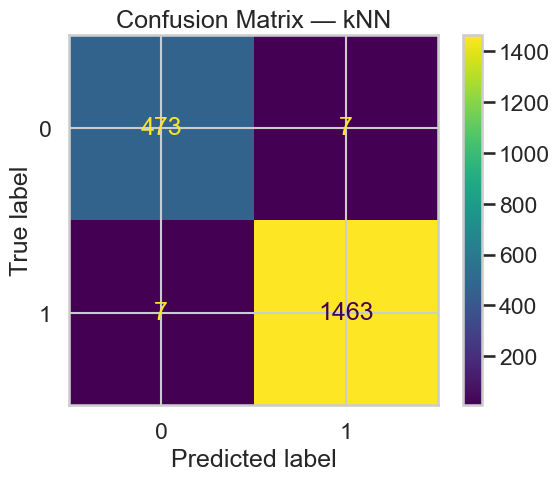

In [18]:

ConfusionMatrixDisplay.from_predictions(y_test, knn_predictions)
plt.title("Confusion Matrix — kNN")
plt.show()


### Анализ различных параметров k для KNN-модели

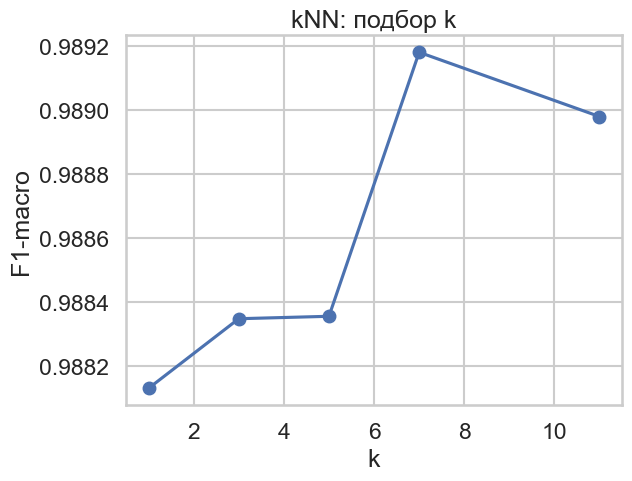

In [19]:
from sklearn.model_selection import cross_val_score

k_values = [1,3,5,7,11]
scores = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    cv = cross_val_score(model, X, y, cv=5, scoring="f1_macro")
    scores.append(cv.mean())

plt.plot(k_values, scores, marker="o")
plt.title("kNN: подбор k")
plt.xlabel("k")
plt.ylabel("F1-macro")
plt.show()

## Эксперимент: Попробуем убрать один из весомых признаков

In [20]:
reduced_features = [f for f in feature_columns if f != "alcohol"]
X_red = wine_dataframe[reduced_features]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_red, y, test_size=0.3, stratify=y, random_state=42
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train_r, y_train_r)
pred = model.predict(X_test_r)

print("Без alcohol F1:", f1_score(y_test_r, pred, average="macro"))

Без alcohol F1: 0.9889300306978764


## Эксперимент: проведём кросс-валидацию

In [22]:
cv_scores = cross_val_score(logreg_pipeline, X, y, cv=5, scoring="f1_macro")
print("CV F1:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())

CV F1: [0.98433875 0.98967979 0.99275133 0.98954537 0.9958448 ]
Mean: 0.990432006281214
Std: 0.003825109849938874



## Итоговые выводы

- Задача корректно формулируется как бинарная классификация (red vs white)
- Logistic Regression показывает очень высокое качество
- kNN также работает хорошо, но немного уступает при среднем значении k=5
- После подбора параметра k для KNN, мы получили более высокую точность
- Масштабирование признаков важно для стабильной работы моделей
- Химические характеристики вина хорошо разделяют классы
- alcohol, density, acidity — сильнее всего влияют на разделение классов.
- чаще путаются белые вина, близкие по химическим характеристикам к красным.
- Кросс-валидация показала стабильные результаты и низкую дисперсию, что говорит о хорошей обобщающей способности модели
- Даже после того, как был убран признак "Алкоголь", модель сохранила высокую точность, так как другие признаки также сильно влияют на категорию вина
- Задача сама по себе простая (см. прошлый пункт), поэтому и высокая точность (утечек нет)
